In [3]:
import sys
sys.path.append('../')
import  os
num_cores = "1"
os.environ["OPENBLAS_NUM_THREADS"] = num_cores
os.environ["OMP_NUM_THREADS"] = num_cores
os.environ["MKL_NUM_THREADS"] = num_cores

from scipy.ndimage import gaussian_filter

import qutip as qt
import utils_2Q_gate_zp as ut
import numpy as np
import matplotlib.pyplot as plt
workers=150




def plot_evolution(hspace, tlist, props, logical = [0,2], intermediate=9, divide=10, s = 0.1, suptitle=""):

    # Get population of logical states, intermediate states, and other states < or >= divide
    pops = np.zeros((2, 5, len(props)))
    logical_idx = [hspace.index(i) for i in logical]
    int_idx = hspace.index(intermediate)
    others_low = [i for i in range(props[0].shape[0]) if i not in logical_idx and i != int_idx and hspace[i] < divide]
    others_high = [i for i in range(props[0].shape[0]) if i not in logical_idx and i != int_idx and hspace[i] >= divide]
    f, ax = plt.subplots(ncols=2, figsize=(8,3))
    for i in range(len(logical_idx)):
        pops[i,0] = np.abs([p[logical_idx[0], i] for p in props])**2
        pops[i,1] = np.abs([p[logical_idx[1], i] for p in props])**2
        pops[i,2] = np.abs([p[int_idx, i] for p in props])**2
        for o in others_low:
            pops[i,3] += np.abs([p[o, i] for p in props])**2
        for o in others_high:
            pops[i,4] += np.abs([p[o, i, ] for p in props])**2

        ax[i].plot(tlist, gaussian_filter(pops[i, 0], s), label=logical[0])
        ax[i].plot(tlist, gaussian_filter(pops[i, 1], s),label=logical[1])
        ax[i].plot(tlist, gaussian_filter(pops[i, 2], s), label=intermediate)
        ax[i].plot(tlist, gaussian_filter(pops[i, 3], s), label=f"others < {divide}")
        ax[i].plot(tlist, gaussian_filter(pops[i, 4], s), label=f"others >= {divide}")
        ax[i].legend()
        ax[i].set_title("Start in " + str(hspace[i]))
        ax[i].set_xlabel("time (ns)")
        ax[i].set_ylabel("population")
    if suptitle != "":
        plt.suptitle(suptitle)
    return pops

def plot_evolution2(hspace, tlist, props, logical = [0, 2], intermediate=9, s = 0.01, suptitle=""):

    # Get population of logical states, intermediate states, and other states < or >= divide
    pops = np.zeros((2, 4, len(props)))
    logical_idx = [hspace.index(i) for i in logical]
    int_idx = hspace.index(intermediate)
    # others_high = [i for i in range(props[0].shape[0]) if i not in logical_idx and i != int_idx and hspace[i] >= divide]
    f, ax = plt.subplots(ncols=2, figsize=(8,3))
    for i in range(len(logical_idx)):
        pops[i,0] = np.abs([p[logical_idx[0], i] for p in props])**2
        pops[i,1] = np.abs([p[logical_idx[1], i] for p in props])**2
        pops[i,2] = np.abs([p[int_idx, i] for p in props])**2
        pops[i,3] = 1-pops[i,0]-pops[i,1]-pops[i,2]
        # for p in range(len(props)):
        #     pops[i,3,p] = 1 - np.sum(pops[i, :3, p])

        ax[i].plot(tlist, gaussian_filter(pops[i, 0], s), label=logical[0])
        ax[i].plot(tlist, gaussian_filter(pops[i, 1], s),label=logical[1])
        ax[i].plot(tlist, gaussian_filter(pops[i, 2], s), label=intermediate)
        ax[i].plot(tlist, gaussian_filter(pops[i, 3], s), label=f"others")
        ax[i].legend()
        ax[i].set_title("Start in " + str(hspace[i]))
        ax[i].set_xlabel("time (ns)")
        ax[i].set_ylabel("population")
    if suptitle != "":
        plt.suptitle(suptitle)
    return pops

# Define System Hamiltonian

In [2]:
# trunc1 = 1000
# [H0, drive_term, w_trans_1, w_trans_2, hspace_charge] = ut.zero_pi_initialize(drive_phi=True, drive_theta=True, truncation=trunc1, thresh=0)
# H0 = H0 - H0[0,0]

In [4]:
# Save to npz for julia
savename = "H_exp.npz"
trunc1 = 1000
if os.path.exists(savename):
    params = np.load(savename)
    H0 = qt.Qobj(params["H0"])
    drive_term = qt.Qobj(params["drive"])
    w_trans_1 = params["w_trans_1"]
    w_trans_2 = params["w_trans_2"]
    hspace_charge = params["hspace_reduced"]
    trunc_model = params["trunc_model"]
    hspace_full=np.arange(trunc1)
else:
    [H0, drive_term, w_trans_1, w_trans_2, hspace_charge] = ut.zero_pi_initialize(drive_phi=True, drive_theta=True, truncation=trunc1, thresh=0)
    from truncation_estimate import trunc_by_graph_estimate
    trunc_model = trunc_by_graph_estimate(500, [0, 2, 9], drive_term, np.abs(np.diag(H0.full())), [w_trans_1, w_trans_2], [0.03, 0.03])
    np.savez(savename, H0=H0, drive=drive_term, w_trans_1=w_trans_1, w_trans_2=w_trans_2, hspace_reduced=hspace_charge, trunc_model=trunc_model, hspace_full=np.arange(trunc1))

In [4]:
# [H0, drive_term, w_trans_1, w_trans_2, hspace_charge] = ut.zero_pi_initialize(drive_phi=True, drive_theta=True, truncation=trunc1, thresh=0)
# from truncation_estimate import trunc_by_graph_estimate
# trunc_model = trunc_by_graph_estimate(500, [0, 2, 9], drive_term, np.abs(np.diag(H0.full())), [w_trans_1, w_trans_2], [0.25, 0.25])
# np.savez(savename, H0=H0, drive=drive_term, w_trans_1=w_trans_1, w_trans_2=w_trans_2, hspace_reduced=hspace_charge, trunc_model=trunc_model, hspace_full=np.arange(trunc1))

## Evaluate Truncated Hamiltonian for Optimization

In [5]:
sorted(trunc_model[:20])

[0, 2, 9, 10, 15, 16, 18, 19, 23, 25, 31, 33, 37, 40, 42, 46, 55, 57, 66, 69]

In [6]:
drive_term[2, 9],drive_term[0, 9]

(0.12104355454701268j, 0.29941167894919857j)

In [7]:
0.025/0.4

0.0625

In [8]:

hspace_reduced = sorted(trunc_model[:100])
tg, amp_A, amp_B, detune_A, detune_B = [828.759495, 0.013563, 0.034964, -0.003029, -0.003182] 
argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_reduced, 2, tg,
                amp_A, amp_B, detune_A, detune_B]
ut.xgate_fidelity_log(argz, True)

0.0

In [9]:
hspace_reduced = sorted(trunc_model[:100])
tg, amp_A, amp_B, detune_A, detune_B = [828.759495, 0.013563, 0.034964, -0.003029, -0.003182] 
argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_reduced, 2, tg,
                amp_A, amp_B, detune_A, detune_B]
ut.xgate_fidelity_log(argz, False)

-2.8645449745296085

In [ ]:
# hspace_reduced = [0, 2, 9]
# hspace_reduced = [0, 2, 9, 10, 11, 16, 19, 23, 25, 31, 33]
# hspace_reduced = [0, 2, 9, 10, 11, 16, 18, 19, 31, 33, 37, 46, 53, 55, 69, 76, 92, 100, 126]
# hspace_reduced = [0, 2, 9, 10, 11, 15, 16, 18, 19, 25, 31, 33, 37, 46, 53, 55, 57, 69, 76, 77, 83, 91, 92, 95, 100, 121, 126, 154]
hspace_reduced = sorted(trunc_model[:100])
# amp = 0.031
# amp = 0.035
# amp = 0.5
amp = 0.259
detune = -0.004
sigma = 200
d_ratio = drive_term[2, 9]/drive_term[0, 9]
# tg, amp_A, amp_B, detune_A, detune_B, alpha_A = [4*sigma, d_ratio*amp, amp, detune, detune, 0.0]
# tg, amp_A, amp_B, detune_A, detune_B = [816.821953, 0.02, 0.05, -0.003212, -0.003123]
# tg, amp_A, amp_B, detune_A, detune_B = [809.06574262, 0.01351718, 0.03533094, -0.00325336, -0.00342939]


# -2.2
tg, amp_A, amp_B, detune_A, detune_B = [820.83640262, 0.01341172, 0.03601629, -0.00333564, -0.00343929]

# - 2.8
# tg, amp_A, amp_B, detune_A, detune_B = [828.759495, 0.013563, 0.034964, -0.003029, -0.003182] 

pulse_args = {'drive_amp_A': amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
             'alpha_A': 0,
             'alpha_B': 0 }
# tg_base = 500
# tg = tg_base+tg_mod

# argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_reduced, workers, tg,
#                 amp_A/(np.exp(2)-1), amp_B/(np.exp(2)-1), detune_A, detune_B]

# H, tlist, num_cpus, c_op_list, pulse_args, logi_idx

# Hlist = [ut.truncate_2(H0, hspace_reduced), [ut.truncate_2(drive_term, hspace_reduced), ut.drive_gauss_A_normalized], [ut.truncate_2(drive_term, hspace_reduced), ut.drive_gauss_B_normalized]]

Hlist = [ut.truncate_2(H0, hspace_reduced), [ut.truncate_2(drive_term, hspace_reduced), ut.drive_gauss_A], [ut.truncate_2(drive_term, hspace_reduced), ut.drive_gauss_B]]

tlist = np.linspace(0, tg, 200)
num_cpus = 4
props = ut.get_propagator(Hlist, tlist, num_cpus, c_op_list=[], pulse_args=pulse_args,
                                 logi_idx=[hspace_reduced.index(0), hspace_reduced.index(2)], return_all=True)

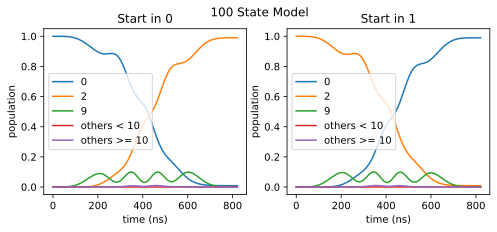

In [11]:
plot_evolution(hspace_reduced, tlist, props, s = 0.01, suptitle=f"{len(hspace_reduced)} State Model");

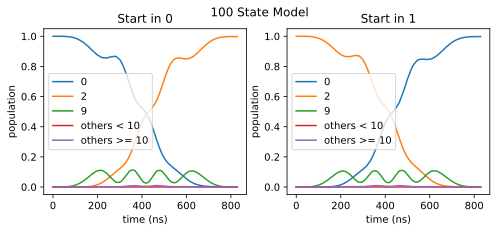

In [9]:
plot_evolution(hspace_reduced, tlist, props, s = 0.01, suptitle=f"{len(hspace_reduced)} State Model");

-2.8645449745296085

In [11]:
def eval_fid_trunc(n):
    argz = [H0, drive_term, w_trans_1, w_trans_2, list(trunc_model[:n]), 1, tg,
                amp_A, amp_B, detune_A, detune_B]
    return ut.xgate_fidelity_log(argz)
def eval_fid_thresh(n):
    argz = [H0, drive_term, w_trans_1, w_trans_2, list(hspace_charge[:n]), 1, tg,
                amp_A, amp_B, detune_A, detune_B]
                
    return ut.xgate_fidelity_log(argz)
from joblib import Parallel, delayed
from tqdm import tqdm

In [12]:
n_states = np.arange(10, 200)
trunc_file = "trunc_fid2.npz"
if os.path.exists(trunc_file):
    res = np.load(trunc_file)
    res_trunc = res["res_trunc"]
    res_charge = res["res_charge"]
else:
    res_trunc = Parallel(n_jobs=len(n_states), verbose=10)(delayed(eval_fid_trunc)(x) for x in n_states)
    res_charge = Parallel(n_jobs=len(n_states), verbose=10)(delayed(eval_fid_thresh)(x) for x in n_states)
    np.savez(trunc_file, res_trunc=res_trunc, res_charge=res_charge)

[Parallel(n_jobs=190)]: Using backend LokyBackend with 190 concurrent workers.


[Parallel(n_jobs=190)]: Done  11 out of 190 | elapsed:   34.3s remaining:  9.3min
[Parallel(n_jobs=190)]: Done  31 out of 190 | elapsed:   42.7s remaining:  3.6min
[Parallel(n_jobs=190)]: Done  51 out of 190 | elapsed:   53.8s remaining:  2.4min
[Parallel(n_jobs=190)]: Done  71 out of 190 | elapsed:  1.2min remaining:  2.1min
[Parallel(n_jobs=190)]: Done  91 out of 190 | elapsed:  1.5min remaining:  1.7min
[Parallel(n_jobs=190)]: Done 111 out of 190 | elapsed:  1.9min remaining:  1.3min
[Parallel(n_jobs=190)]: Done 131 out of 190 | elapsed:  2.3min remaining:  1.0min
[Parallel(n_jobs=190)]: Done 151 out of 190 | elapsed:  2.8min remaining:   43.1s
[Parallel(n_jobs=190)]: Done 171 out of 190 | elapsed:  3.3min remaining:   22.1s
[Parallel(n_jobs=190)]: Done 190 out of 190 | elapsed:  4.0min finished
[Parallel(n_jobs=190)]: Using backend LokyBackend with 190 concurrent workers.
[Parallel(n_jobs=190)]: Done  11 out of 190 | elapsed:   16.0s remaining:  4.3min
[Parallel(n_jobs=190)]: Done 

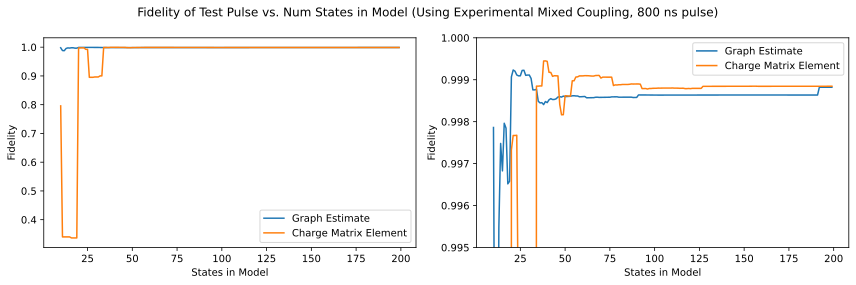

In [14]:
f, ax = plt.subplots(ncols=2, figsize=(12,4))

plt.suptitle("Fidelity of Test Pulse vs. Num States in Model (Using Experimental Mixed Coupling, 800 ns pulse)")

ax[0].plot(n_states, 1-10**np.array(res_trunc), label="Graph Estimate")
ax[0].plot(n_states, 1-10**np.array(res_charge), label="Charge Matrix Element")
ax[0].set_xlabel("States in Model")
ax[0].legend()
ax[0].set_ylabel("Fidelity");

ax[1].plot(n_states, 1-10**np.array(res_trunc), label="Graph Estimate")
ax[1].plot(n_states, 1-10**np.array(res_charge), label="Charge Matrix Element")
# ax[1].xscale("log")
# ax[1].yscale("log")
ax[1].set_xlabel("States in Model")
ax[1].set_ylim(0.995, 1)
ax[1].legend()
ax[1].set_ylabel("Fidelity");
plt.tight_layout()

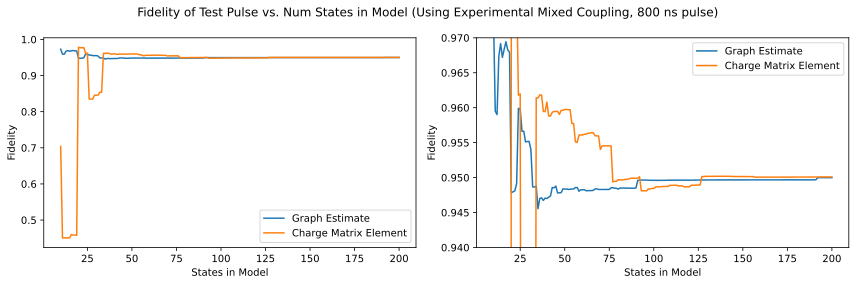

In [32]:
f, ax = plt.subplots(ncols=2, figsize=(12,4))

plt.suptitle("Fidelity of Test Pulse vs. Num States in Model (Using Experimental Mixed Coupling, 800 ns pulse)")

ax[0].plot(n_states, 1-10**np.array(res_trunc), label="Graph Estimate")
ax[0].plot(n_states, 1-10**np.array(res_charge), label="Charge Matrix Element")
ax[0].set_xlabel("States in Model")
ax[0].legend()
ax[0].set_ylabel("Fidelity");

ax[1].plot(n_states, 1-10**np.array(res_trunc), label="Graph Estimate")
ax[1].plot(n_states, 1-10**np.array(res_charge), label="Charge Matrix Element")
# ax[1].xscale("log")
# ax[1].yscale("log")
ax[1].set_xlabel("States in Model")
ax[1].set_ylim(0.94, 0.97)
ax[1].legend()
ax[1].set_ylabel("Fidelity");
plt.tight_layout()

In [ ]:

p1 = ut.drive_gauss_A_normalized(tlist, pulse_args)

In [5]:
# tlist, props = ut.xgate_propagator(argz, num=300)

Drive params

In [6]:
# tg_wiggle, amp_A, amp_B, detune_A, detune_B, alpha_A = [-1.61880996, 0.5638094, 0.66464448, -0.22691617, -0.47345273, 0]
# tg_wiggle, amp_A, amp_B, detune_A, detune_B, alpha_A = [-2.02513517, 0.21160303,  0.10911951, -0.03935263 , 0.02558899 , 0.        ]
# tg = 100+tg_wiggle

# tg_wiggle, amp_A, amp_B, detune_A, detune_B, alpha_A = [0.9029999310786319, 0.022073592159162141, 0.0231926859121433, -0.006843538348239284, -0.004178164800861717, 0.0]
# tg = 200+tg_wiggle

# tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [-1.6022618941335471, 0.014731532341970145, 0.04062198110780239, 0.007618929777842787, 0.007262639488947169, 0.0]
# tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [0.11268125555080166, 0.014142995072423321, 0.0451642879632784, 0.008161080248434104, 0.007455826806149466, 0.0]
# tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [0.17210174360195618, 0.01469954169804958, 0.041345842433731385, 0.007670946255372147, 0.007379191702328314, 0.0]
# tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [0.1576606188670021, 0.014449240167381897, 0.04175966257613523, 0.007586777312143744, 0.007195356460595284, 0.0]
# tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [2.4600279830210994, 0.028442903814433672, 0.05000539864309156, 0.017478615677518, 0.01873037628081732, 0.0]
# tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [2.4340298374814577, 0.028729421919342073, 0.05234007853388449, 0.018377931157072456, 0.019468242015868924, 0.0]
# tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [2.418798148507539, 0.02732140722161542, 0.05125185058492317, 0.01701831741043452, 0.01801286286187182, 0.0]
tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [2.4817536489456793, 0.02755483304039716, 0.047044443096421404, 0.01595110143999065, 0.01736804591088877, 0.0]
tg_base = 500
tg = tg_base+tg_mod

# tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [-0.9725005346101057, 0.03701630999864878, 0.0625537809977427, 0.0192521737451147, 0.02018914994841529, 0.0]
# tg_base = 800
# tg = tg_base + tg_mod

# tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [0.7931350386642599, 0.01376931681864476, 0.015968337320101306, 0.003859050119665002, 0.005118450809580633, 0.0]
# tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [0.7931350386642599, 0.01376931681864476, 0.015968337320101306, 0.003859050119665002, 0.005118450809580633, 0.0]
# [1.2453917063382254, 0.016452422519164747, 0.04051852563774717, -0.004422532570081743, -0.004649376203684997, 0.0]
# tg_base = 1000
# tg = tg_base+tg_mod

pulse_args = {'drive_amp_A': amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
             'alpha_A': alpha_A,
             'alpha_B': 0 }
pulse_args

{'drive_amp_A': 0.02755483304039716,
 'drive_freq_A': 50.99409092841711,
 'drive_amp_B': 0.047044443096421404,
 'drive_freq_B': 29.624309598350546,
 'gate_time': 502.4817536489457,
 'alpha_A': 0.0,
 'alpha_B': 0}

In [7]:
drive_term.shape

(1000, 1000)

(0.12104355454701268j, 0.29941167894919857j, (0.4042713195818599+0j))

# Show fidelities and plot populations

In [27]:
2*np.pi*0.005/0.121

0.25963575649502424

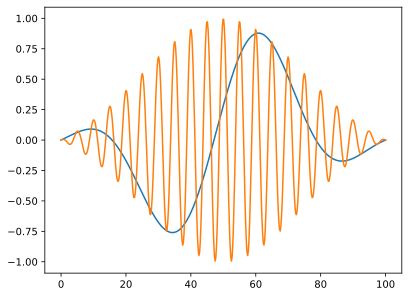

In [10]:
pulse_args = {'drive_amp_A': 1 ,
            'drive_freq_A': 1/10,
            'drive_amp_B': 1 ,
            'drive_freq_B': 2*np.pi*1/5,
            'gate_time': 100,
             'alpha_A': 0,
             'alpha_B': 0 }
tlist = np.linspace(0, 100, 500)
p1 = [ut.drive_gauss_A_normalized(t, pulse_args) for t in tlist]
p2 = [ut.drive_gauss_B_normalized(t, pulse_args) for t in tlist]
plt.plot(tlist, p1)
plt.plot(tlist, p2)

## Paper-Like Pulse

In [13]:
# Approx drive params for paper
d_ratio = drive_term[2, 9]/drive_term[0, 9]
drive_term[2, 9], drive_term[0, 9], drive_term[2, 9]/drive_term[0, 9] #[trunc_states.index(state0), trunc_states.index(state1)])

(0.12104355454701268j, 0.29941167894919857j, (0.4042713195818599+0j))

In [15]:
0.005*2*np.pi/0.121

0.25963575649502424

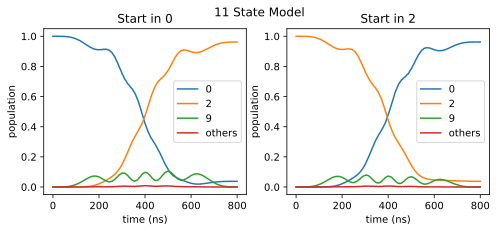

In [21]:
# hspace_reduced = [0, 2, 9]
hspace_reduced = [0, 2, 9, 10, 11, 16, 19, 23, 25, 31, 33]
# hspace_reduced = [0, 2, 9, 10, 11, 16, 18, 19, 31, 33, 37, 46, 53, 55, 69, 76, 92, 100, 126]
# hspace_reduced = [0, 2, 9, 10, 11, 15, 16, 18, 19, 25, 31, 33, 37, 46, 53, 55, 57, 69, 76, 77, 83, 91, 92, 95, 100, 121, 126, 154]
# hspace_reduced = sorted(trunc_model[:150])
# amp = 0.031
# amp = 0.035
# amp = 0.5
amp = 0.259
detune = -0.004
sigma = 200
tg, amp_A, amp_B, detune_A, detune_B, alpha_A = [4*sigma, d_ratio*amp, amp, detune, detune, 0.0]
pulse_args = {'drive_amp_A': amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
             'alpha_A': alpha_A,
             'alpha_B': 0 }
# tg_base = 500
# tg = tg_base+tg_mod

argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_reduced, workers, tg,
                amp_A, amp_B, detune_A, detune_B, 0, 0]

# H, tlist, num_cpus, c_op_list, pulse_args, logi_idx

Hlist = [ut.truncate_2(H0, hspace_reduced), [ut.truncate_2(drive_term, hspace_reduced), ut.drive_gauss_A_normalized], [ut.truncate_2(drive_term, hspace_reduced), ut.drive_gauss_B_normalized]]
tlist = np.linspace(0, tg, 200)
num_cpus = 4
props = ut.get_propagator(Hlist, tlist, num_cpus, c_op_list=[], pulse_args=pulse_args,
                                 logi_idx=[hspace_reduced.index(0), hspace_reduced.index(2), hspace_reduced.index(9)], return_all=True)
plot_evolution2([0, 2, 9], tlist, props, s = 0.01, suptitle=f"{len(hspace_reduced)} State Model");

## Longer Pulse

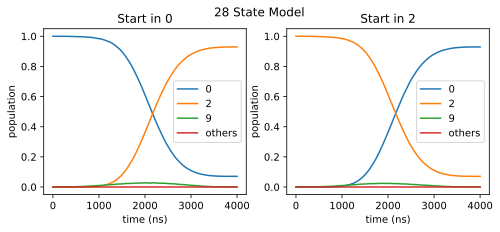

In [87]:
# hspace_reduced = [0, 2, 9]
# hspace_reduced = [0, 2, 9, 10, 11, 16, 19, 23, 25, 31, 33]
# hspace_reduced = [0, 2, 9, 10, 11, 16, 18, 19, 31, 33, 37, 46, 53, 55, 69, 76, 92, 100, 126]
hspace_reduced = [0, 2, 9, 10, 11, 15, 16, 18, 19, 25, 31, 33, 37, 46, 53, 55, 57, 69, 76, 77, 83, 91, 92, 95, 100, 121, 126, 154]
# amp = 0.031
amp = 0.0125
# amp = 0.259
detune = -0.004
sigma = 1000
tg, amp_A, amp_B, detune_A, detune_B, alpha_A = [4*sigma, d_ratio*amp, amp, detune, detune, 0.0]
pulse_args = {'drive_amp_A': amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
             'alpha_A': alpha_A,
             'alpha_B': 0 }
# tg_base = 500
# tg = tg_base+tg_mod

argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_reduced, workers, tg,
                amp_A, amp_B, detune_A, detune_B, 0, 0]

# H, tlist, num_cpus, c_op_list, pulse_args, logi_idx

Hlist = [ut.truncate_2(H0, hspace_reduced), [ut.truncate_2(drive_term, hspace_reduced), ut.drive_gauss_A], [ut.truncate_2(drive_term, hspace_reduced), ut.drive_gauss_B]]
tlist = np.linspace(0, tg, 200)
num_cpus = 4
props = ut.get_propagator(Hlist, tlist, num_cpus, c_op_list=[], pulse_args=pulse_args,
                                 logi_idx=[hspace_reduced.index(0), hspace_reduced.index(2), hspace_reduced.index(9)], return_all=True)
plot_evolution2([0, 2, 9], tlist, props, s = 0.01, suptitle=f"{len(hspace_reduced)} State Model");

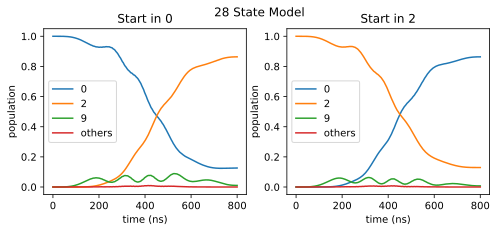

In [78]:
plot_evolution2([0, 2, 9], tlist, props, s = 0.01, suptitle=f"{len(hspace_reduced)} State Model");

(0.0001, 1)

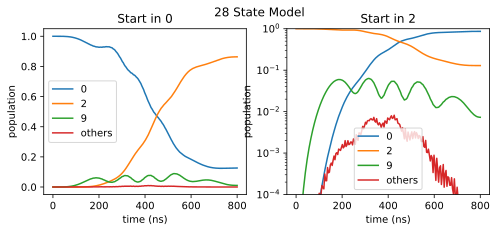

In [72]:
plot_evolution2([0, 2, 9], tlist, props, s = 0.01, suptitle=f"{len(hspace_reduced)} State Model");
plt.gca().set_yscale("log")
plt.gca().set_ylim(1e-04, 1)

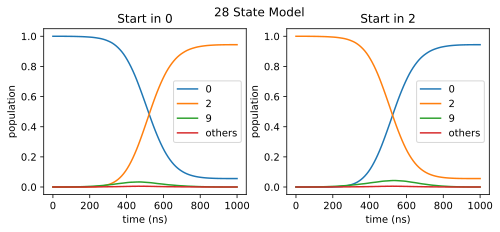

In [13]:

plot_evolution2([0, 2, 9], tlist, props, s = 1, suptitle=f"{len(hspace_reduced)} State Model");

In [13]:
props[50]

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = False
Qobj data =
[[ 0.85790944+0.12740066j -0.13221969-0.01066276j  0.47876669+0.03600967j]
 [-0.03254261+0.12817497j  0.26521125-0.82688657j  0.11403699-0.46446183j]
 [ 0.45543973+0.14854833j  0.45388243+0.1467537j  -0.71458354-0.16857179j]]

In [7]:
# Save to npz for julia
np.savez("H_phi.npz", H0=H0, drive=drive_term, w_trans_1=w_trans_1, w_trans_2=w_trans_2, hspace_reduced=hspace_reduced, hspace_full=np.arange(trunc1))

In [8]:
ut.xgate_fidelity(argz)
plot_evolution(hspace_reduced, tlist, props, s = 1, suptitle="16 State Model");


-4.570405051032363

In [9]:
tlist, props = ut.xgate_propagator(argz, num=300)

(1e-05, 1)

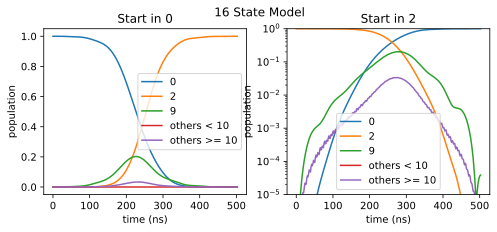

In [10]:
plot_evolution(hspace_reduced, tlist, props, s = 1, suptitle="16 State Model");
plt.gca().set_yscale("log")
plt.gca().set_ylim(1e-05, 1)

In [11]:
hspace_full = list(np.arange(300))
argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_full, workers, tg,
                amp_A, amp_B, detune_A, detune_B, alpha_A, 0]

In [12]:
ut.xgate_fidelity(argz)

-2.3176711055581376

In [13]:
tlist, props = ut.xgate_propagator(argz, num=300)

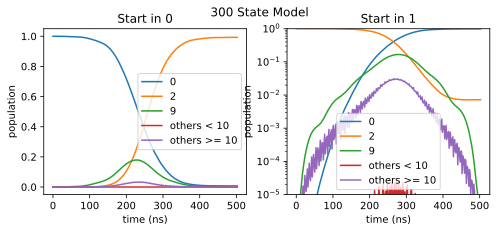

In [14]:
plot_evolution(hspace_full, tlist, props, suptitle="300 State Model");
plt.gca().set_yscale("log")
plt.gca().set_ylim(1e-05, 1);

# Old -- Rotating Frame

Look at dynamics in a roatating frame:

$$
U = |0\rangle\langle 0|e^{-i(E_9-\omega_A)t} + |2\rangle\langle 2|e^{-i(E_9-\omega_B)t} + |9\rangle\langle 9|e^{-iE_9t}
$$
and for other $n$:
$$
|n\rangle\langle n|e^{-iE_9t}
$$



In [15]:
def U(t, E_int, pulse_args, hspace, logical_idx = [0,1], intermediate=9):
    u = np.zeros((len(hspace), len(hspace)), dtype=np.complex128)
    for i in range(len(hspace)):
        if i == logical_idx[0]:
            u[i,i] = np.exp(-1.0j*(E_int - pulse_args["drive_freq_A"])*t)
        elif i == logical_idx[1]:
            u[i,i] = np.exp(-1.0j*(E_int - pulse_args["drive_freq_B"])*t)
        else:
            u[i,i] = np.exp(1.0j*E_int*t)
    
    return u

plot_evolution(argz, U = lambda t: U(t, w_trans_1, pulse_args, hspace_reduced));

TypeError: plot_evolution() got an unexpected keyword argument 'U'

# Other

In [ ]:
# 500 ns phi gate
# Differential_evolution step 908: f(x)= -3.79937
# Best Soln: [-1.58325328, 0.20769485, 0.5965205, 0.32459243, 0.33639606, 0]
# convergence 0.0564